# 03. Organoid growth chart with PCNtoolkit BLR

Velasco protocol, y = `frac_NPC_IP` (neural progenitor fraction), x = `age` (days in culture).

Plan (TASKS_day1.md, B line):
- **B1** minimal BLR, homoskedastic, B-spline on age -> `results/blr_homo/`
- **B2** heteroskedastic -> `results/blr_hetero/`; + batch effect `publication` -> `results/blr_hetero_batch/`
- **B3** calibration plots

Template: the Oct 2 tutorial notebook (section 4, cell "Model 1: Gaussian BLR").

## Step 1. Check the installed PCNtoolkit and its API

The API changed a lot at version 1.0 (2025), so we print the actual function signatures instead of trusting memory.
The four objects we will use, same as in the tutorial:
- `NormData.from_dataframe(...)`: wraps a pandas DataFrame (which columns are covariates / responses / batch effects).
- `BsplineBasisFunction(...)`: lets the mean curve bend.
- `BLR(...)`: the model template (options: heteroskedastic, fixed_effect, warp_name ...).
- `NormativeModel(template)`: fits, predicts, computes z-scores and centiles.

In [1]:
import sys, inspect
import pcntoolkit
from pcntoolkit import BLR, BsplineBasisFunction, NormData, NormativeModel

print("Python:", sys.version.split()[0], "   executable:", sys.executable)
print("PCNtoolkit:", pcntoolkit.__version__)

# Print messages for every step would be noisy; turn them off (as in the tutorial).
pcntoolkit.util.output.Output.set_show_messages(False)

Python: 3.12.14    executable: /Users/libot/miniconda3/envs/normative/bin/python
PCNtoolkit: 1.3.0


In [2]:
# The actual signatures of the installed version (do not assume an API from memory).
for obj in [NormData.from_dataframe, BsplineBasisFunction.__init__, BLR.__init__, NormativeModel.__init__]:
    print(obj.__qualname__)
    print("   ", inspect.signature(obj), "\n")

print("NormativeModel methods we will use: fit, predict, fit_predict, compute_centiles, compute_zscores, evaluate")
print("Have them all:", all(hasattr(NormativeModel, m) for m in
      ["fit", "predict", "fit_predict", "compute_centiles", "compute_zscores", "evaluate"]))

NormData.from_dataframe
    (name: 'str', dataframe: 'pd.DataFrame', covariates: 'List[str] | None' = None, batch_effects: 'List[str] | None' = None, response_vars: 'List[str | LiteralString] | None' = None, subject_ids: 'str | None' = None, remove_Nan: 'bool' = False, remove_outliers: 'bool' = False, z_threshold: 'float' = 3.0, attrs: 'Mapping[str, Any] | None' = None) -> 'NormData' 

BsplineBasisFunction.__init__
    (self, basis_column: 'int' = 0, degree: 'int' = 3, nknots: 'int' = 5, left_expand: 'float' = 0.05, right_expand: 'float' = 0.05, knot_method: 'str' = 'uniform', knots: 'np.ndarray | list' = None, **kwargs) 

BLR.__init__
    (self, name: 'str' = 'template', fixed_effect: 'bool' = False, fixed_effect_slope: 'bool' = False, fixed_effect_slope_indices: "list[int] | Literal['all']" = None, heteroskedastic: 'bool' = False, fixed_effect_var: 'bool' = False, fixed_effect_var_slope: 'bool' = False, fixed_effect_var_slope_indices: "list[int] | Literal['all']" = None, warp_name: '

## Step 2. Load the data, filter Velasco, merge the fixed train/test split

- `data/hnoca_sample_composition.csv`: 322 samples, one row each.
- Keep the Velasco **protocol** (131 samples). Not the publication "Velasco, 2019" (21 samples).
- `data/split_velasco.csv`: fixed split, 105 train / 26 test, stratified by age bin. Always use it, never refit the split.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("..")                      # notebook lives in notebooks/, repo root is one level up
DATA = ROOT / "data"

df_all = pd.read_csv(DATA / "hnoca_sample_composition.csv")
print("all samples:", df_all.shape)

# Velasco protocol only (the protocol string contains a DOI, so match on the name).
df = df_all[df_all["protocol"].str.contains("Velasco")].copy()
print("Velasco protocol:", df.shape)

# Merge the fixed train/test labels. 'inner' keeps only samples present in both tables.
split = pd.read_csv(DATA / "split_velasco.csv")
df = df.merge(split, on="sample", how="inner")
print("after merge:", df.shape, "   split counts:", df["split"].value_counts().to_dict())

train = df[df["split"] == "train"].reset_index(drop=True)
test = df[df["split"] == "test"].reset_index(drop=True)
assert len(train) == 105 and len(test) == 26, "unexpected split sizes"

cols = ["sample", "age", "publication", "frac_NPC_IP", "split"]
train[cols].head()

all samples: (322, 28)
Velasco protocol: (131, 28)
after merge: (131, 29)    split counts: {'train': 105, 'test': 26}


,sample,age,publication,frac_NPC_IP,split
0,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,70,"Bhaduri, 2020",0.241908,train
1,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,70,"Bhaduri, 2020",0.512422,train
2,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,105,"Bhaduri, 2020",0.195103,train
3,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,168,"Bhaduri, 2020",0.036186,train
4,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,168,"Bhaduri, 2020",0.043568,train


                count  min  max
publication                    
Bhaduri, 2020      17   21  168
Paulsen, 2022      54   28  190
Uzquiano, 2022     39   23  192
Velasco, 2019      21  101  190

count    131.000
mean       0.302
std        0.271
min        0.015
25%        0.080
50%        0.130
75%        0.577
max        0.912
Name: frac_NPC_IP, dtype: float64


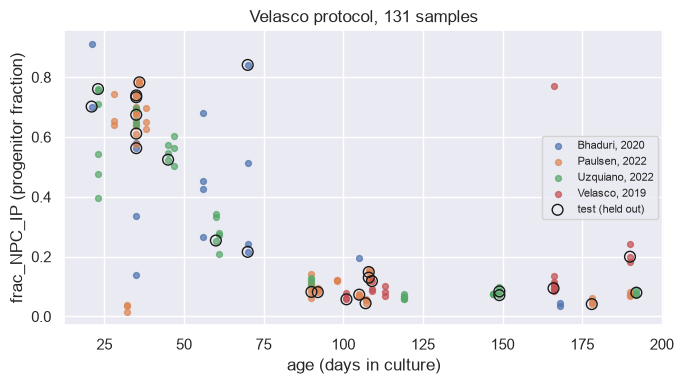

In [4]:
# Quick look: age range per publication, and the y variable.
print(df.groupby("publication")["age"].agg(["count", "min", "max"]))
print()
print(df["frac_NPC_IP"].describe().round(3))

fig, ax = plt.subplots(figsize=(7, 4))
for pub, g in df.groupby("publication"):
    ax.scatter(g["age"], g["frac_NPC_IP"], s=18, alpha=0.7, label=pub)
ax.scatter(test["age"], test["frac_NPC_IP"], s=60, facecolors="none", edgecolors="k", label="test (held out)")
ax.set_xlabel("age (days in culture)")
ax.set_ylabel("frac_NPC_IP (progenitor fraction)")
ax.set_title("Velasco protocol, 131 samples")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()